27.885 personas tomaron semaglutida o tirzepatida. Una sola variante en tu ADN puede **triplicar** el riesgo de vómitos — pero solo con uno de los dos fármacos.

---

**Paper:** *Genetic predictors of GLP1 receptor agonist weight loss and side effects*
**DOI:** [10.1038/s41586-026-10330-z](https://doi.org/10.1038/s41586-026-10330-z)
**Datos:** Supplementary Data (Nature)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-09-predictores-geneticos-glp1-perdida-peso/notebook.ipynb)

## El problema de la variabilidad

Ozempic, Wegovy, Mounjaro, Zepbound — los agonistas del receptor GLP1 transformaron el tratamiento de la obesidad. Pero la respuesta varía enormemente: hay quien pierde el 20% de su peso corporal y quien apenas baja un 2%.

Un equipo de 23andMe reunió a 27.885 personas en tratamiento con estos fármacos y buscó en su genoma qué variantes predicen dos cosas: cuánto peso pierdes y qué efectos secundarios sufres. Lo que encontraron sienta las bases para la medicina de precisión en obesidad.

In [1]:
# ==============================================================
# Configuración — modifica estos valores para explorar
# ==============================================================
FUENTE = 'Fuente: 23andMe et al. (2026), Nature | Supplementary Data'
COLOR_TIRZ = '#2563EB'
COLOR_SEMA = '#059669'
COLOR_ALERTA = '#DC2626'
COLOR_REF = '#D97706'
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

efectos = pd.read_csv('datos/efectos_genotipo.csv')
farmacos = pd.read_csv('datos/resumen_farmacos.csv')
variantes = pd.read_csv('datos/variantes_gwas.csv')
modelo = pd.read_csv('datos/modelo_eficacia.csv')
rendimiento = pd.read_csv('datos/rendimiento_modelo.csv')
gwas_peso = pd.read_csv('datos/gwas_peso_cambio.csv')
gwas_fenotipos = pd.read_csv('datos/gwas_resumen_fenotipos.csv')

print(f"Participantes: 27.885 (4.908 hombres + 22.977 mujeres)")
print(f"Variantes GWAS significativas: {len(variantes)}")
print(f"SNPs con p < 1x10-4 (cambio de peso): {len(gwas_peso)}")
print(f"Fenotipos analizados: {len(gwas_fenotipos)}")
print()
print("Fármacos: Ozempic, Wegovy, Mounjaro, Zepbound + compuestos")

Participantes: 27.885 (4.908 hombres + 22.977 mujeres)
Variantes GWAS significativas: 9
SNPs con p < 1x10-4 (cambio de peso): 1626
Fenotipos analizados: 39

Fármacos: Ozempic, Wegovy, Mounjaro, Zepbound + compuestos


## Una variante, dos fármacos, tres veces más riesgo

Aquí está.

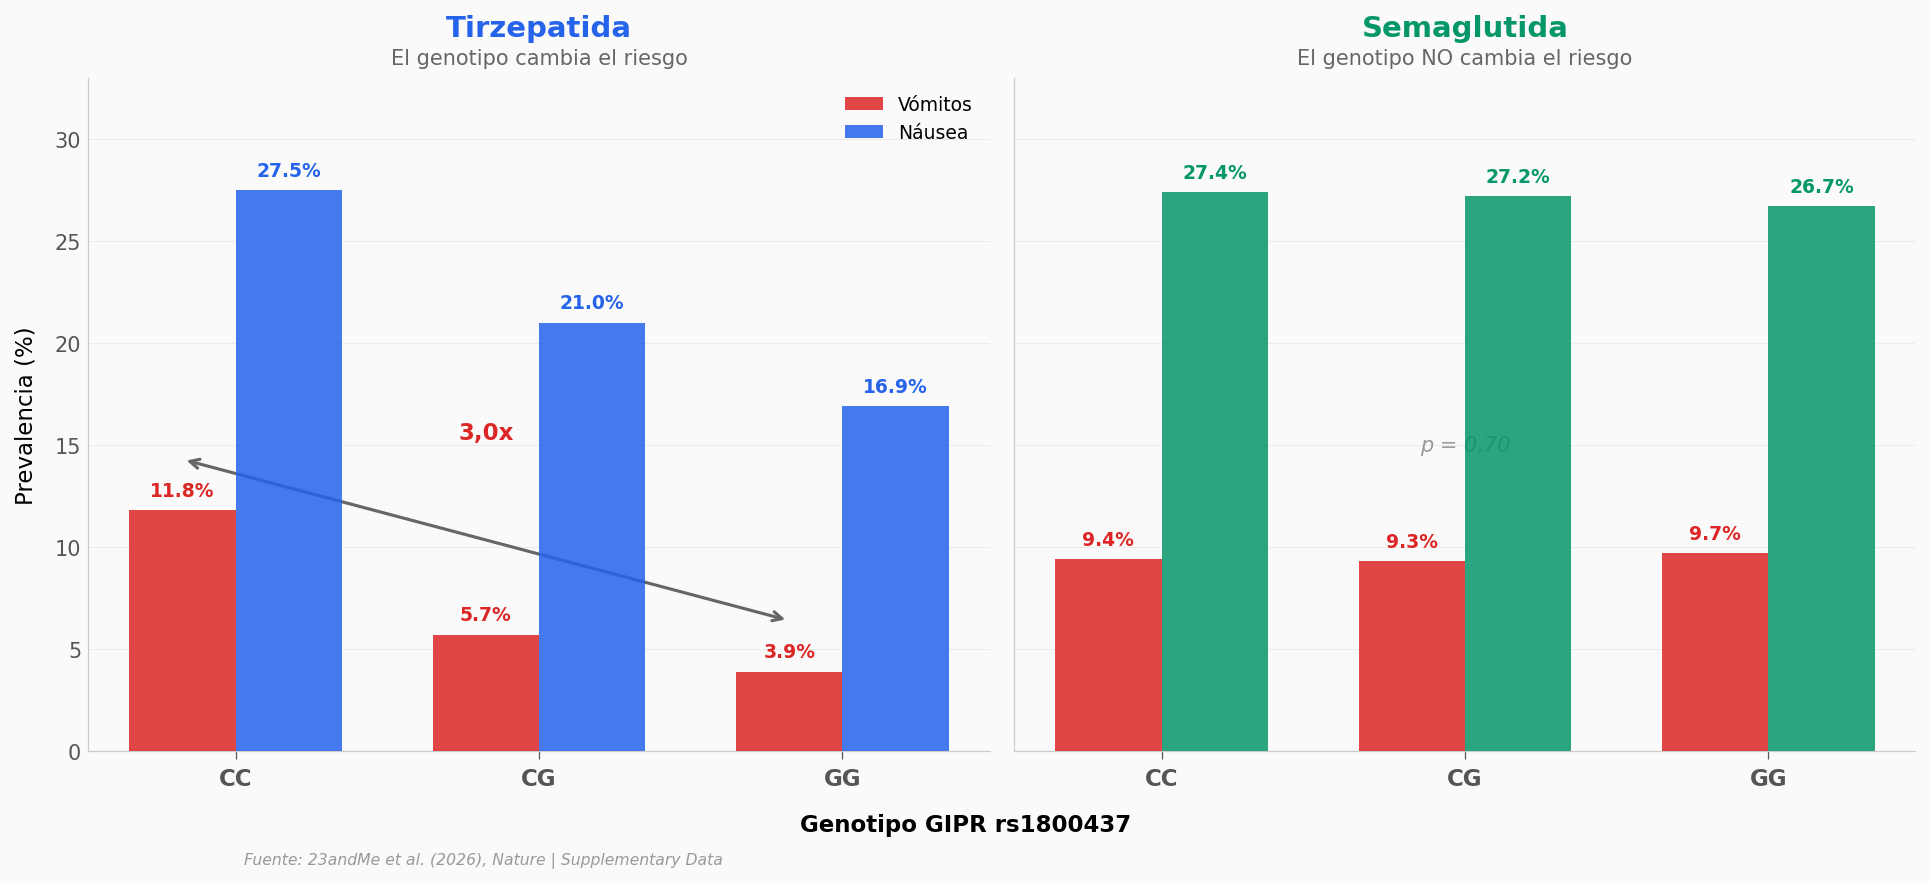

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

genotipos = ['CC', 'CG', 'GG']
x = np.arange(len(genotipos))
width = 0.35

# Panel izquierdo: Tirzepatida
vom_tirz = efectos[(efectos['efecto'] == 'vomiting') & (efectos['farmaco'] == 'tirzepatide')]
nau_tirz = efectos[(efectos['efecto'] == 'nausea') & (efectos['farmaco'] == 'tirzepatide')]

vom_vals_t = [vom_tirz[vom_tirz['genotipo'] == g]['prevalencia_pct'].values[0] for g in genotipos]
nau_vals_t = [nau_tirz[nau_tirz['genotipo'] == g]['prevalencia_pct'].values[0] for g in genotipos]

bars1 = ax1.bar(x - width/2, vom_vals_t, width, color=COLOR_ALERTA, alpha=0.85,
                label='Vómitos', zorder=5)
bars2 = ax1.bar(x + width/2, nau_vals_t, width, color=COLOR_TIRZ, alpha=0.85,
                label='Náusea', zorder=5)

for bar, val in zip(bars1, vom_vals_t):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=COLOR_ALERTA)
for bar, val in zip(bars2, nau_vals_t):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=COLOR_TIRZ)

ax1.set_title('Tirzepatida', fontsize=14, fontweight='bold', pad=20, color=COLOR_TIRZ)
ax1.text(0.5, 1.02, 'El genotipo cambia el riesgo',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax1.set_xticks(x)
ax1.set_xticklabels(genotipos, fontsize=11, fontweight='bold')
ax1.set_ylabel('Prevalencia (%)', fontsize=11)
ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax1.set_ylim(0, 33)

ax1.annotate('', xy=(0 - width/2, vom_vals_t[0] + 2.5),
             xytext=(2 - width/2, vom_vals_t[2] + 2.5),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax1.text(1 - width/2, max(vom_vals_t[0], vom_vals_t[2]) + 3.5, '3,0x',
         ha='center', fontsize=11, fontweight='bold', color=COLOR_ALERTA)

# Panel derecho: Semaglutida
vom_sema = efectos[(efectos['efecto'] == 'vomiting') & (efectos['farmaco'] == 'semaglutide')]
nau_sema = efectos[(efectos['efecto'] == 'nausea') & (efectos['farmaco'] == 'semaglutide')]

vom_vals_s = [vom_sema[vom_sema['genotipo'] == g]['prevalencia_pct'].values[0] for g in genotipos]
nau_vals_s = [nau_sema[nau_sema['genotipo'] == g]['prevalencia_pct'].values[0] for g in genotipos]

bars3 = ax2.bar(x - width/2, vom_vals_s, width, color=COLOR_ALERTA, alpha=0.85, zorder=5)
bars4 = ax2.bar(x + width/2, nau_vals_s, width, color=COLOR_SEMA, alpha=0.85, zorder=5)

for bar, val in zip(bars3, vom_vals_s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=COLOR_ALERTA)
for bar, val in zip(bars4, nau_vals_s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=COLOR_SEMA)

ax2.set_title('Semaglutida', fontsize=14, fontweight='bold', pad=20, color=COLOR_SEMA)
ax2.text(0.5, 1.02, 'El genotipo NO cambia el riesgo',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')
ax2.set_xticks(x)
ax2.set_xticklabels(genotipos, fontsize=11, fontweight='bold')

ax2.text(1, max(vom_vals_s) + 5, 'p = 0,70',
         ha='center', fontsize=10, color='#999999', style='italic')

fig.text(0.5, -0.02, 'Genotipo GIPR rs1800437', ha='center', fontsize=11, fontweight='bold')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/interaccion_gen_farmaco.png', dpi=200, bbox_inches='tight')
plt.show()

El gradiente del panel izquierdo es inequívoco. En personas que toman tirzepatida (Mounjaro, Zepbound), el genotipo CC del gen GIPR se asocia con un 11,8% de prevalencia de vómitos — el triple que el 3,9% del genotipo GG. El test de tendencia entre los tres genotipos (CC, CG, GG) confirma la asociación (chi-cuadrado = 44,5, p = 2,2 x 10 a la -10). La náusea sigue el mismo patrón: 27,5% vs 16,9% (p = 4,6 x 10 a la -8).

El panel derecho lo pone en perspectiva. Para semaglutida, la misma variante genética no tiene ningún efecto (p = 0,70 para vómitos). Los tres genotipos rondan el 9,4%.

¿Por qué? Tirzepatida actúa sobre DOS receptores: GLP1R y GIPR. La variante rs1800437 está en el gen GIPR. Si tu GIPR tiene el genotipo CC, tirzepatida activa una señal gastrointestinal que semaglutida — que solo toca GLP1R — no activa.

## ¿Y la pérdida de peso?

Los efectos secundarios son la mitad de la historia. La otra es cuánto peso se pierde — y qué fármaco lo logra.

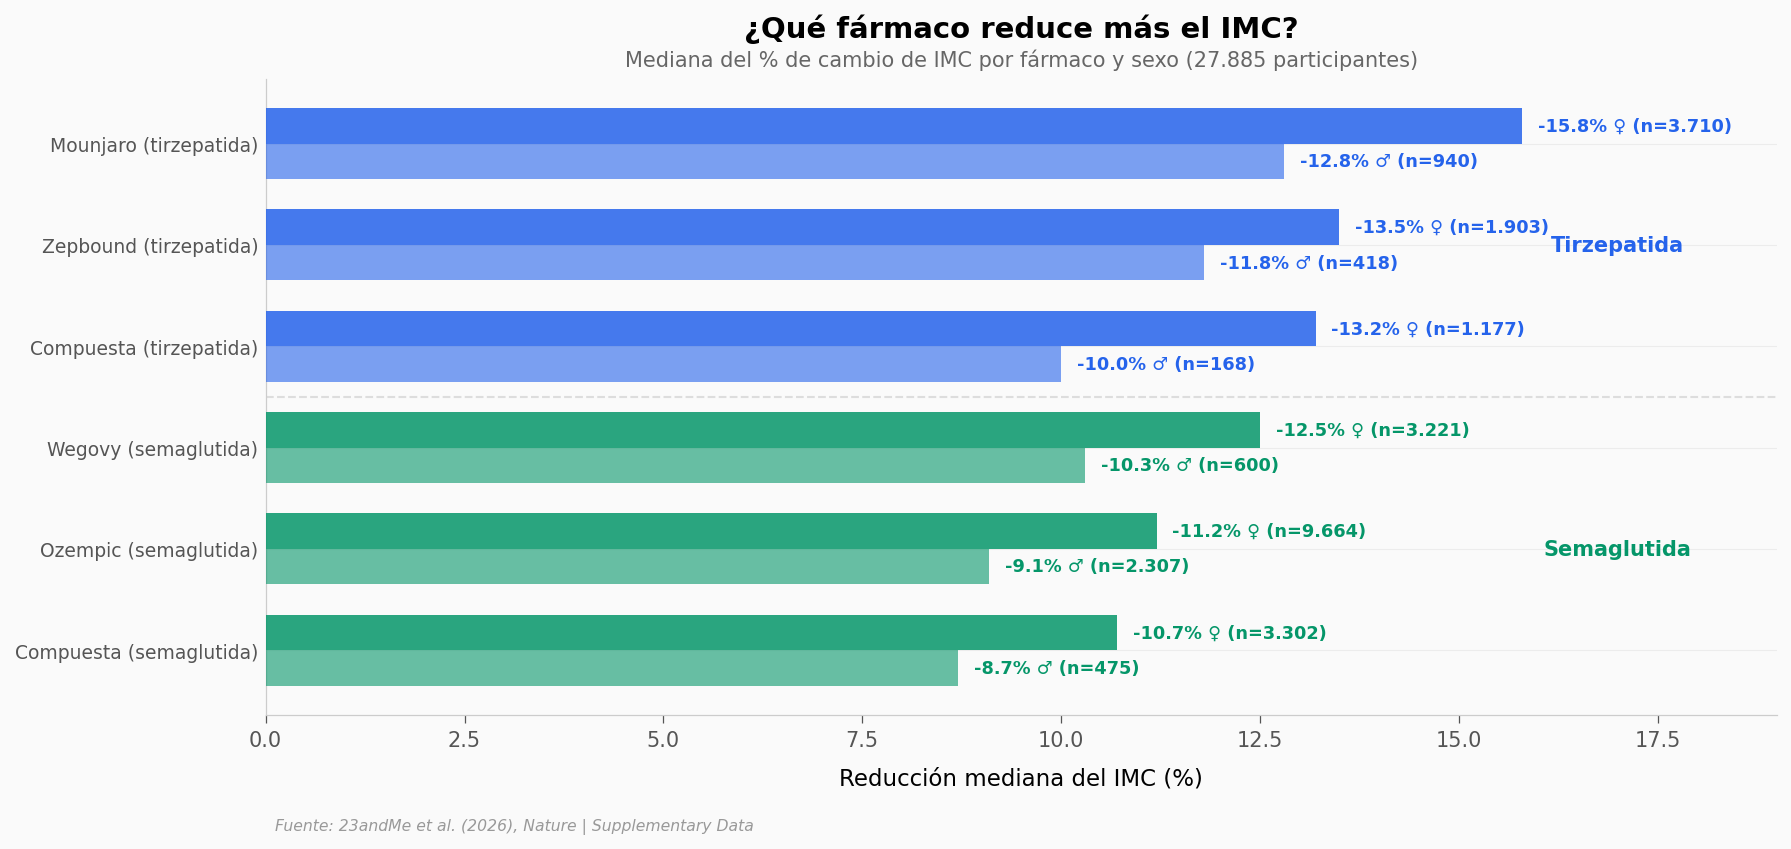

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

drugs_order = ['Mounjaro', 'Zepbound', 'Compounded_tirzepatide',
               'Wegovy', 'Ozempic', 'Compounded_semaglutide']
drug_labels = ['Mounjaro (tirzepatida)', 'Zepbound (tirzepatida)',
               'Compuesta (tirzepatida)',
               'Wegovy (semaglutida)', 'Ozempic (semaglutida)',
               'Compuesta (semaglutida)']

y_pos = np.arange(len(drugs_order))
bar_height = 0.35

for i, drug in enumerate(drugs_order):
    for sex, offset, alpha, marker in [('F', -bar_height/2, 0.85, chr(9792)),
                                        ('M', bar_height/2, 0.6, chr(9794))]:
        row = farmacos[(farmacos['farmaco'] == drug) & (farmacos['sexo'] == sex)]
        if len(row) == 0:
            continue
        bmi_str = row['bmi_change_pct_mediana'].values[0]
        val = float(bmi_str.split('%')[0])
        n = int(row['n'].values[0])

        is_tirz = drug in ['Mounjaro', 'Zepbound', 'Compounded_tirzepatide']
        color = COLOR_TIRZ if is_tirz else COLOR_SEMA

        ax.barh(i + offset, abs(val), height=bar_height,
                color=color, alpha=alpha, zorder=5)
        n_str = f'{n:,}'.replace(',', '.')
        ax.text(abs(val) + 0.2, i + offset,
                f'{val}% {marker} (n={n_str})',
                va='center', fontsize=8.5, color=color, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(drug_labels, fontsize=9)
ax.set_xlabel('Reducción mediana del IMC (%)', fontsize=11)
ax.set_title('¿Qué fármaco reduce más el IMC?', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02,
        'Mediana del % de cambio de IMC por fármaco y sexo (27.885 participantes)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.axhline(y=2.5, color='#DDDDDD', linewidth=1, linestyle='--')
ax.text(17, 1, 'Tirzepatida', fontsize=10, fontweight='bold',
        color=COLOR_TIRZ, ha='center', va='center')
ax.text(17, 4, 'Semaglutida', fontsize=10, fontweight='bold',
        color=COLOR_SEMA, ha='center', va='center')

ax.invert_yaxis()
ax.set_xlim(0, 19)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_farmacos.png', dpi=200, bbox_inches='tight')
plt.show()

Mounjaro lidera: las mujeres que lo toman alcanzan una mediana de -15,8% de IMC. Los hombres, -12,8%. Tirzepatida supera a semaglutida en casi todas las comparaciones (excepción: tirzepatida compuesta vs Wegovy en hombres, -10,0% vs -10,3%).

Pero esas medianas ocultan una dispersión enorme. ¿Qué lo explica?

## Un modelo de medicina de precisión

El equipo construyó un modelo que combina factores clínicos y genéticos para predecir la respuesta. Veamos qué pesa más.

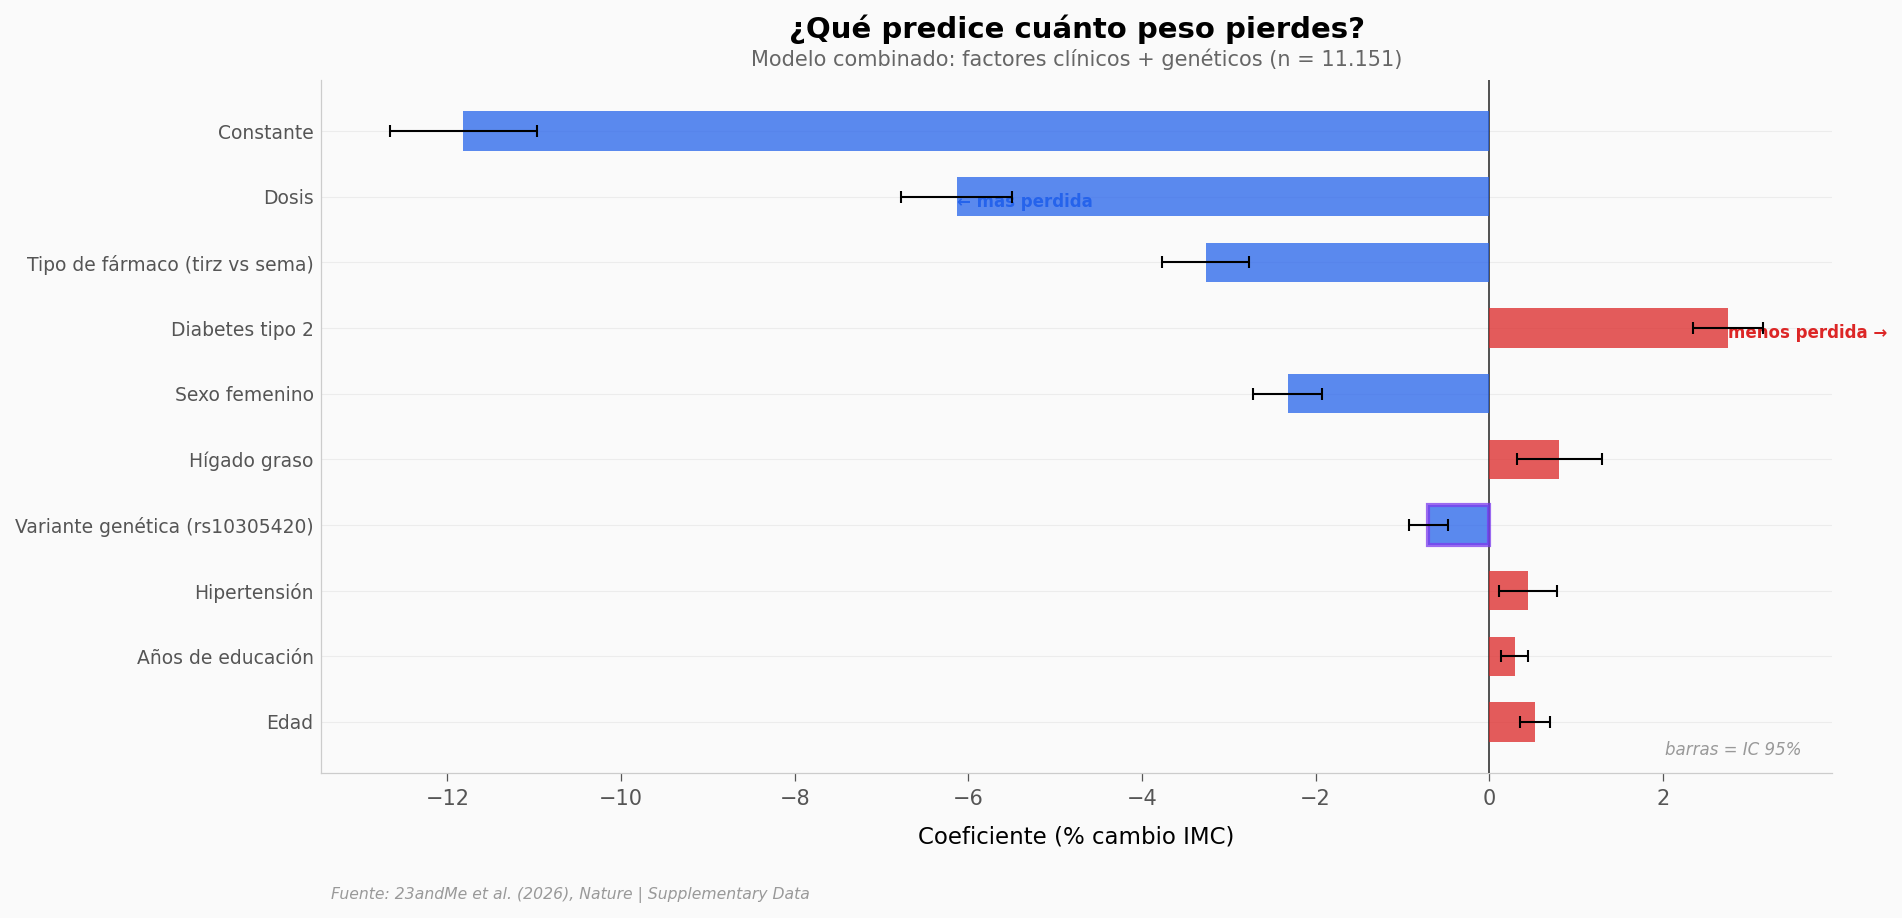

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

main_vars = ['const', 'Dose', 'Drug Type', 'T2D', 'Female Sex', 'NAFLD',
             'GWAS Index SNP*', 'Hypertension', 'Years of Education', 'Age']
labels_es = ['Constante', 'Dosis', 'Tipo de fármaco (tirz vs sema)',
             'Diabetes tipo 2', 'Sexo femenino', 'Hígado graso',
             'Variante genética (rs10305420)', 'Hipertensión',
             'Años de educación', 'Edad']

model_main = modelo[modelo['variable'].isin(main_vars)].copy()
model_main['order'] = model_main['variable'].map(
    {v: i for i, v in enumerate(main_vars)})
model_main = model_main.sort_values('order')

coefs = model_main['coef'].values
stderrs = model_main['stderr'].values
y = np.arange(len(coefs))

colors = [COLOR_TIRZ if c < 0 else COLOR_ALERTA for c in coefs]

bars = ax.barh(y, coefs, xerr=stderrs * 1.96, height=0.6,
               color=colors, alpha=0.75, capsize=3, zorder=5,
               error_kw={'linewidth': 1, 'color': '#666666'})

ax.axvline(x=0, color='#333333', linewidth=0.8, zorder=3)

snp_idx = list(main_vars).index('GWAS Index SNP*')
bars[snp_idx].set_edgecolor(COLOR_VIOLETA)
bars[snp_idx].set_linewidth(2)

ax.set_yticks(y)
ax.set_yticklabels(labels_es, fontsize=9)
ax.set_xlabel('Coeficiente (% cambio IMC)', fontsize=11)
ax.set_title('¿Qué predice cuánto peso pierdes?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02,
        'Modelo combinado: factores clínicos + genéticos (n = 11.151)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(-6.134, 1.15, chr(8592) + ' mas perdida', fontsize=8,
        color=COLOR_TIRZ, fontweight='bold')
ax.text(2.752, 3.15, 'menos perdida ' + chr(8594), fontsize=8,
        color=COLOR_ALERTA, fontweight='bold')

ax.text(0.98, 0.02, 'barras = IC 95%', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax.invert_yaxis()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/modelo_eficacia.png', dpi=200, bbox_inches='tight')
plt.show()

La dosis y el tipo de fármaco dominan — eran esperables. Pero fijémonos en tres hallazgos:

1. **Sexo femenino** (coef = -2,32): las mujeres pierden más peso en promedio, un efecto más grande que la variante genética.
2. **Diabetes tipo 2** (coef = +2,75): los diabéticos pierden menos, probablemente porque la indicación original (control glucémico) compite con el efecto de pérdida de peso.
3. **Variante genética** rs10305420 (coef = -0,70): cada copia del alelo T se asocia con un 0,70% adicional de reducción de IMC (p = 7,9 x 10 a la -10). Es más modesto que el tipo de fármaco, pero es la primera evidencia directa de que una variante en el gen diana contribuye a la variabilidad.

## ¿Puede la genética mejorar las predicciones?

El modelo con genética versus sin genética — ¿cuánto mejora?

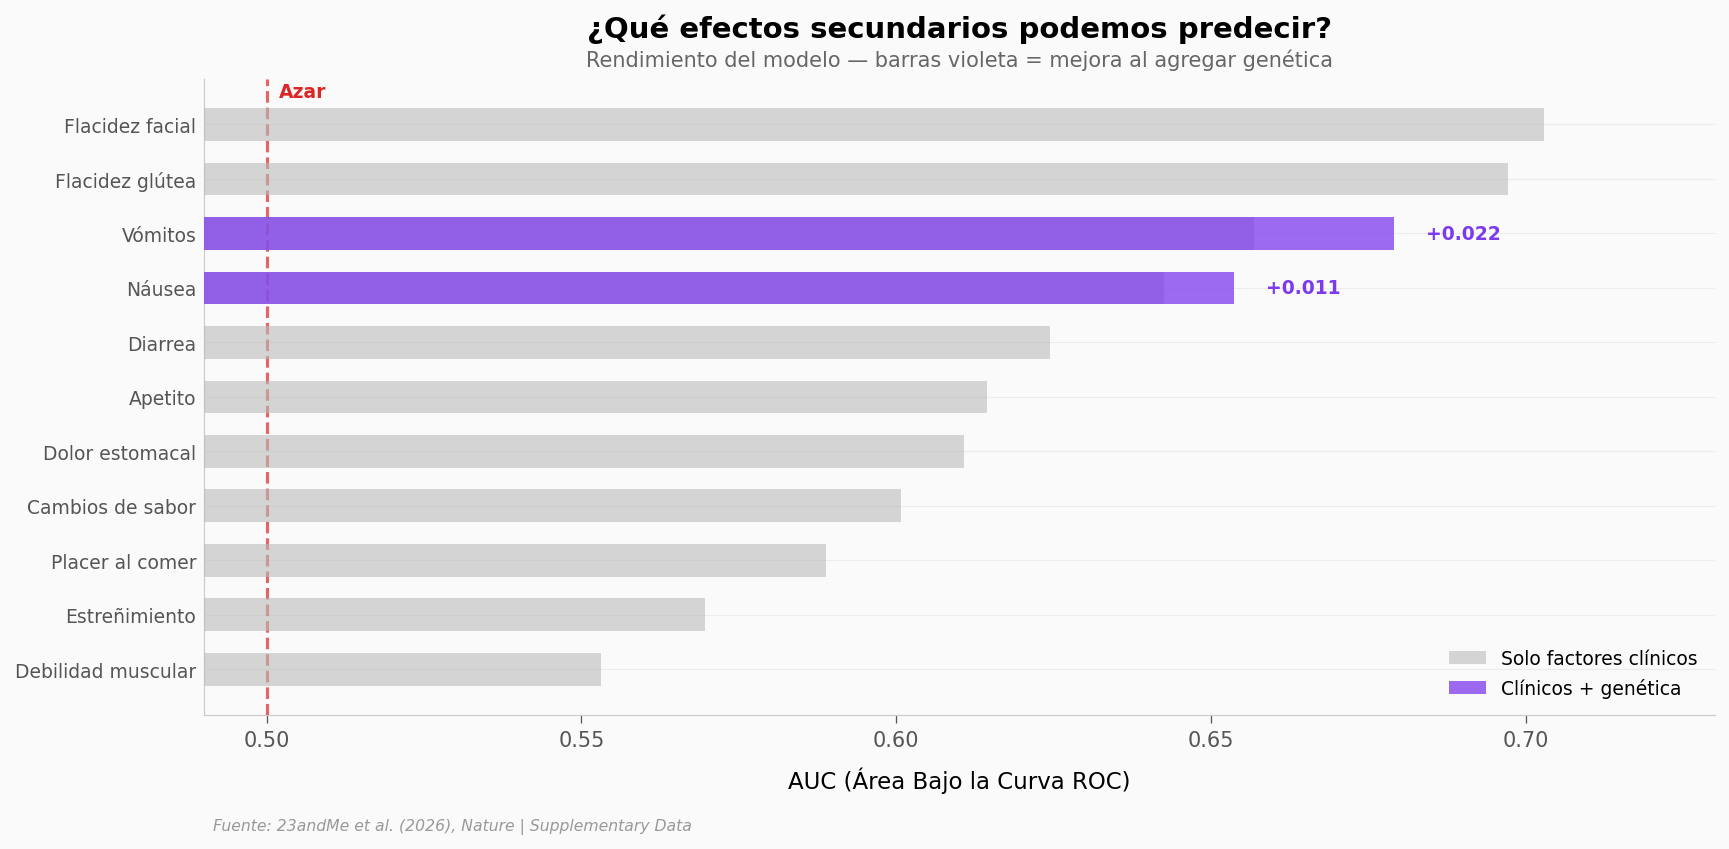

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

side_effects = rendimiento[rendimiento['type'] == 'side_effect'].copy()
side_effects = side_effects.sort_values('auc_without_genetics')

phenotype_labels = {
    'muscle weakness': 'Debilidad muscular',
    'constipation': 'Estreñimiento',
    'pleasure eating': 'Placer al comer',
    'taste': 'Cambios de sabor',
    'stomach pain': 'Dolor estomacal',
    'appetite': 'Apetito',
    'diarrhea': 'Diarrea',
    'nausea': 'Náusea',
    'vomiting': 'Vómitos',
    'butt sagging': 'Flacidez glútea',
    'face sagging': 'Flacidez facial',
}

labels = [phenotype_labels.get(p, p) for p in side_effects['phenotype']]
y = np.arange(len(labels))
auc_no_gen = side_effects['auc_without_genetics'].values

bars = ax.barh(y, auc_no_gen, height=0.6, color=COLOR_GRIS, alpha=0.6,
               zorder=4, label='Sin genética')

for i, (_, row) in enumerate(side_effects.iterrows()):
    if pd.notna(row['auc_with_genetics']):
        delta = row['auc_with_genetics'] - row['auc_without_genetics']
        ax.barh(i, row['auc_with_genetics'], height=0.6,
                color=COLOR_VIOLETA, alpha=0.75, zorder=5)
        ax.text(row['auc_with_genetics'] + 0.005, i,
                f"+{delta:.3f}",
                va='center', fontsize=9, fontweight='bold', color=COLOR_VIOLETA)

ax.axvline(x=0.5, color=COLOR_ALERTA, linewidth=1.5, linestyle='--',
           alpha=0.7, zorder=3)
ax.text(0.502, len(labels) - 0.5, 'Azar', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('AUC (Área Bajo la Curva ROC)', fontsize=11)
ax.set_title('¿Qué efectos secundarios podemos predecir?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02,
        'Rendimiento del modelo — barras violeta = mejora al agregar genética',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0.49, 0.73)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_GRIS, alpha=0.6, label='Solo factores clínicos'),
    Patch(facecolor=COLOR_VIOLETA, alpha=0.75, label='Clínicos + genética')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

Vómitos y náusea son los únicos efectos secundarios donde la genética mejora la predicción (delta AUC = +0,022 y +0,011). Para los demás, la genética disponible no aporta.

La flacidez facial y glútea tienen los AUC más altos (~0,70), pero eso viene de factores clínicos (tiempo en tratamiento, cantidad de peso perdido), no de genética.

Para la eficacia (% de pérdida de IMC), el R cuadrado del modelo es 0,243 con genética y 0,242 sin ella — una mejora de 0,001. La variante rs10305420 aporta, pero la mayor parte de la variabilidad la explican dosis, tipo de fármaco y condiciones preexistentes.

## ¿Dónde están las variantes?

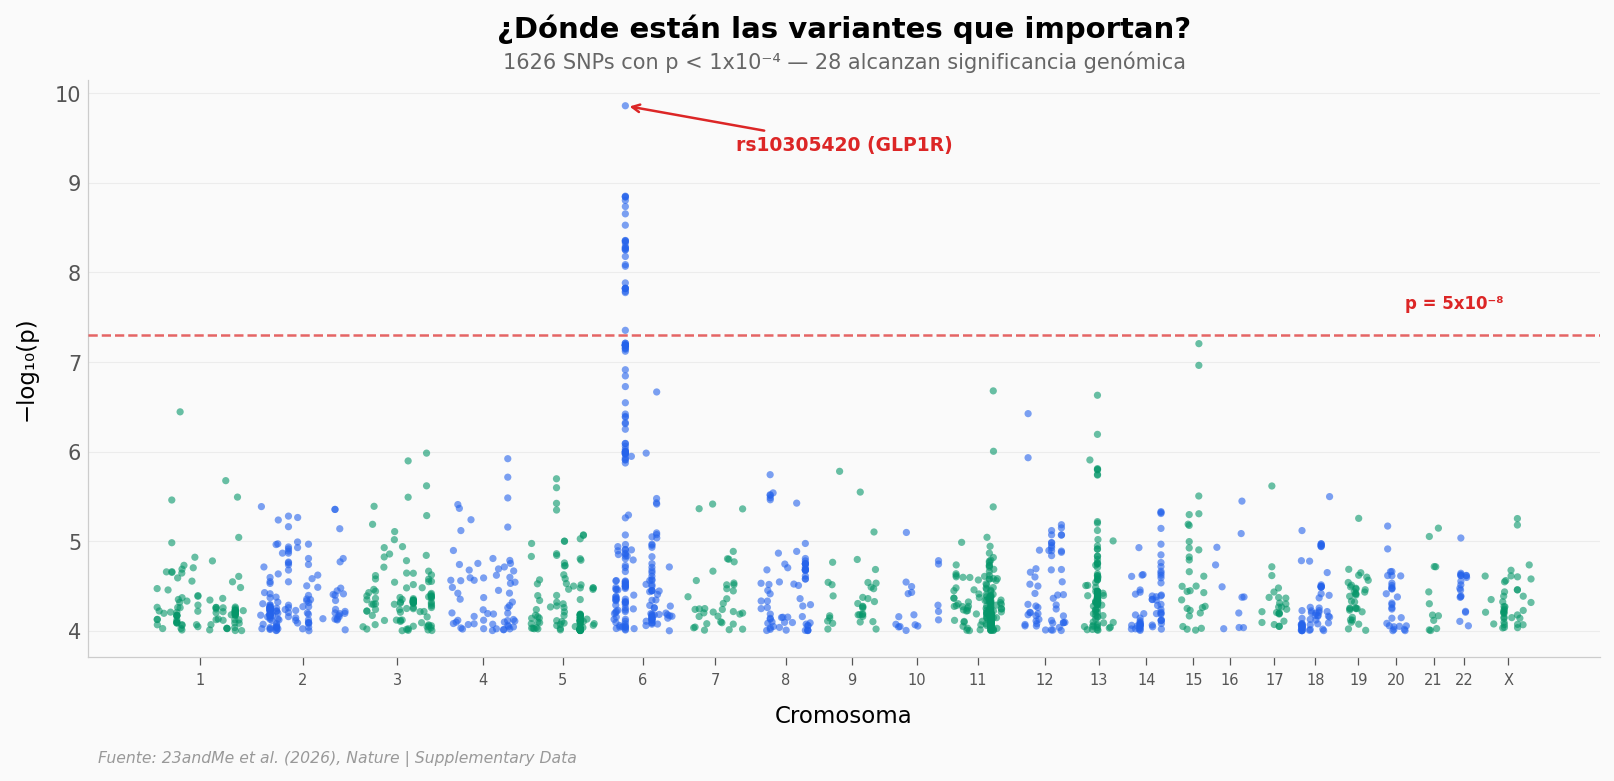

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

gwas = gwas_peso.copy()
# Map chromosome names to numbers (X=23, Y=24, MT=25)
chr_map = {'X': 23, 'Y': 24, 'MT': 25}
gwas['chr_num'] = gwas['CHR'].apply(lambda c: chr_map.get(str(c), int(c) if str(c).isdigit() else None))
gwas = gwas.dropna(subset=['chr_num'])
gwas['chr_num'] = gwas['chr_num'].astype(int)
gwas['neg_log_p'] = -np.log10(gwas['p-value'])

chr_colors = {c: (COLOR_TIRZ if c % 2 == 0 else COLOR_SEMA)
              for c in gwas['chr_num'].unique()}
colors = [chr_colors[c] for c in gwas['chr_num']]

chr_offset = {}
cumulative = 0
for chrom in sorted(gwas['chr_num'].unique()):
    chr_offset[chrom] = cumulative
    sub = gwas[gwas['chr_num'] == chrom]
    cumulative += sub['POS_b38'].max() - sub['POS_b38'].min() + 5e7

gwas['plot_pos'] = gwas.apply(
    lambda r: chr_offset[r['chr_num']] + r['POS_b38'], axis=1)

ax.scatter(gwas['plot_pos'], gwas['neg_log_p'], c=colors,
           s=12, alpha=0.6, edgecolors='none', zorder=4)

gw_threshold = -np.log10(5e-8)
ax.axhline(y=gw_threshold, color=COLOR_ALERTA, linewidth=1.2,
           linestyle='--', alpha=0.7, zorder=3)
ax.text(gwas['plot_pos'].max() * 0.98, gw_threshold + 0.3,
        'p = 5x10\u207b\u2078', fontsize=8,
        color=COLOR_ALERTA, ha='right', fontweight='bold')

top_snp = gwas.loc[gwas['neg_log_p'].idxmax()]
ax.annotate("rs10305420 (GLP1R)", xy=(top_snp['plot_pos'], top_snp['neg_log_p']),
            xytext=(top_snp['plot_pos'] + cumulative * 0.08,
                    top_snp['neg_log_p'] - 0.5),
            fontsize=9, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

chr_labels_map = {23: 'X', 24: 'Y', 25: 'MT'}
chr_centers = {}
for chrom in sorted(gwas['chr_num'].unique()):
    positions = gwas[gwas['chr_num'] == chrom]['plot_pos']
    chr_centers[chrom] = (positions.min() + positions.max()) / 2

ax.set_xticks(list(chr_centers.values()))
ax.set_xticklabels([chr_labels_map.get(c, str(c)) for c in chr_centers.keys()], fontsize=7)
ax.set_xlabel('Cromosoma', fontsize=11)
ax.set_ylabel('\u2212log\u2081\u2080(p)', fontsize=11)
ax.set_title('¿Dónde están las variantes que importan?',
             fontsize=14, fontweight='bold', pad=20)

n_gw = len(gwas[gwas['neg_log_p'] >= gw_threshold])
subtitle = f'{len(gwas)} SNPs con p < 1x10\u207b\u2074 \u2014 {n_gw} alcanzan significancia genómica'
ax.text(0.5, 1.02, subtitle,
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/manhattan_peso.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Variante rs10305420 se asocia con mayor pérdida de peso | ✅ | Efecto = -0,64% IMC por alelo, p = 2,9 x 10 a la -10. El paper reporta -0,76 kg (conversión del modelo ajustado) |
| Genotipo CC triplica riesgo de vómitos en tirzepatida | ✅ | CC 11,8% vs GG 3,9% = 3,0x. Chi-cuadrado = 44,5, p = 2,2 x 10 a la -10 |
| El efecto está restringido a tirzepatida | ✅ | Semaglutida: CC 9,4% vs GG 9,7%, chi-cuadrado = 0,7, p = 0,70 |
| Genética mejora predicción de efectos secundarios | ✅ | AUC vómitos: +0,022 (0,679 vs 0,657). Mejora modesta pero consistente |
| Genética mejora predicción de pérdida de peso | ⚠️ | R cuadrado = 0,243 vs 0,242 (delta = +0,001). Mejora marginal. Dosis y tipo de fármaco dominan |
| Medicina de precisión viable para obesidad | ⚠️ | Los datos identifican variantes relevantes, pero el poder predictivo actual es limitado. El paper dice que estos resultados "sientan las bases" |

> **Limitaciones:** Datos de encuesta auto-reportados (no mediciones clínicas de peso), muestra predominantemente europea (76%), rango limitado de dosis y duración. Los efectos son asociaciones (GWAS), no relaciones causales. El GWAS explica una fracción pequeña de la variabilidad total.

## Ahora tú

1. **¿Cuántos SNPs alcanzan significancia genómica por fenotipo?** Los datos incluyen 39 fenotipos (efectos secundarios + eficacia). Prueba a cargar  y graficar el número de variantes significativas por fenotipo. ¿Cuáles efectos secundarios tienen más señal genética?

2. **¿Hay diferencia por sexo en la prevalencia de efectos secundarios?** Los datos de  incluyen efectos secundarios desglosados por sexo. ¿Los hombres y las mujeres reportan las mismas tasas de náusea y vómitos?

3. **¿La educación realmente importa?** El modelo incluye "Years of Education" como predictor (coef = +0,29, p = 0,0002). ¿Por qué aparecería la educación en un modelo de pérdida de peso? Prueba a visualizar los coeficientes de las interacciones (Dosis x Tipo, Dosis x Días) y piensa en qué variables podrían ser confusoras.

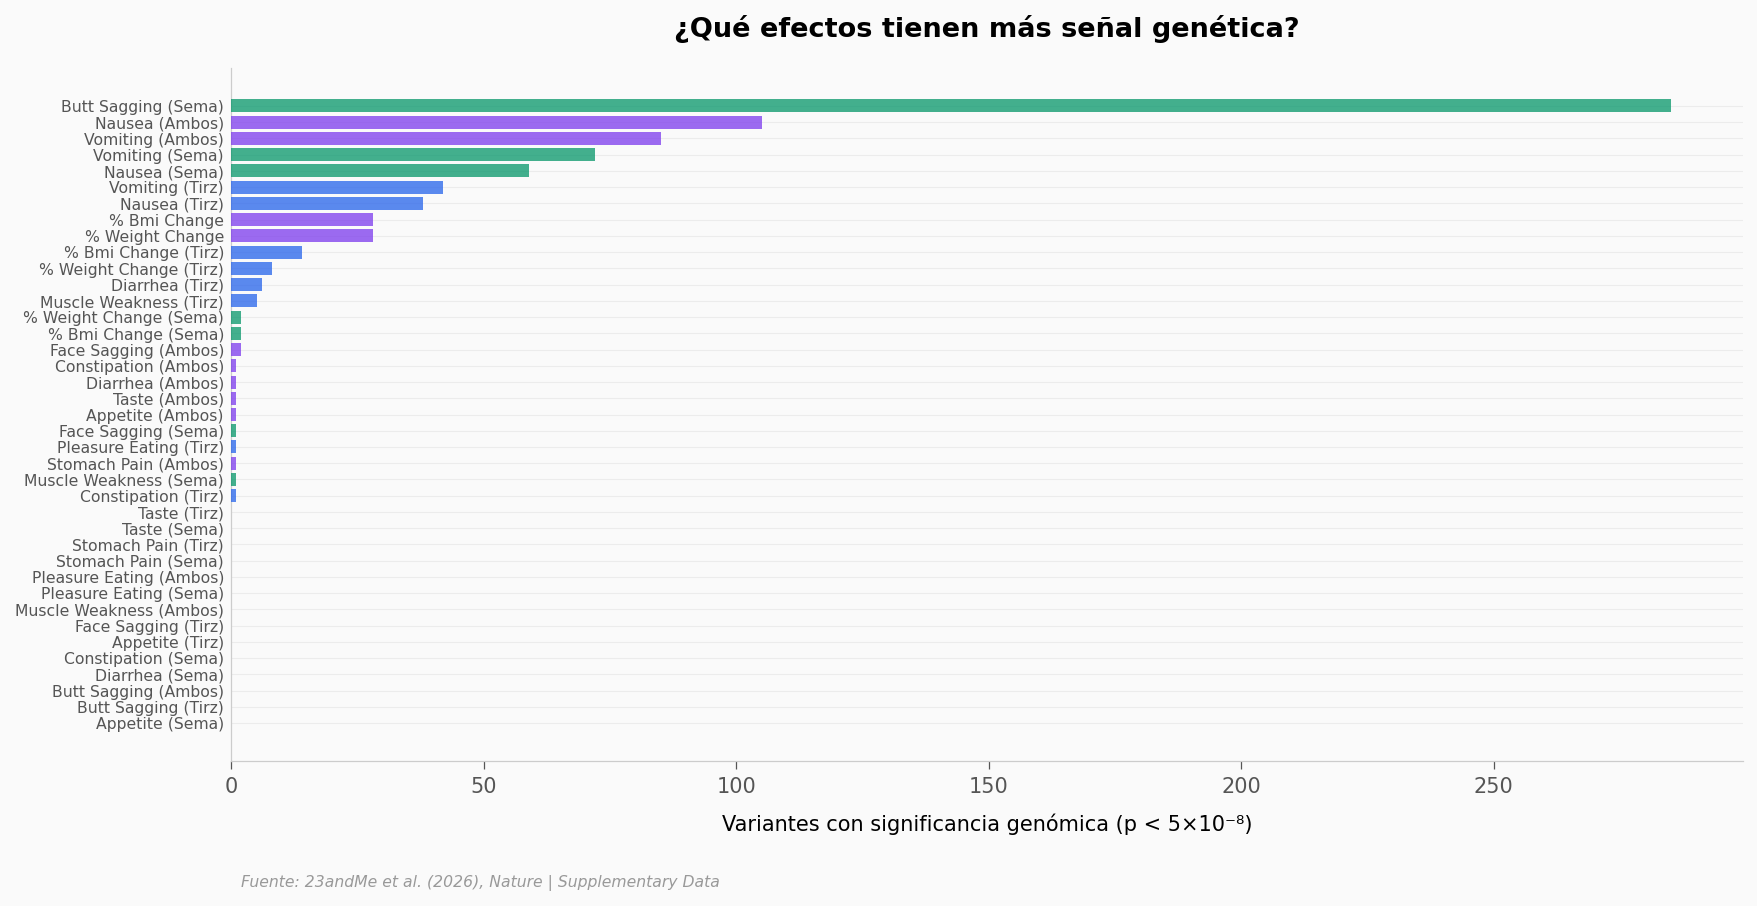

In [7]:
# --- EXPERIMENTA AQUI ---
# Cuales efectos secundarios tienen mas senal genetica?

fig, ax = plt.subplots(figsize=(13, 6))

gf = gwas_fenotipos.sort_values('n_snps_gw_sig', ascending=True)

labels = []
for p in gf['phenotype']:
    label = p.replace('glp_', '').replace('side_effect_', '')
    label = label.replace('prct_', '% ')
    label = label.replace('_semaglutide_or_tirzepatide', ' (ambos)')
    label = label.replace('_semaglutide', ' (sema)')
    label = label.replace('_tirzepatide', ' (tirz)')
    label = label.replace('_', ' ').title()
    labels.append(label)

y = np.arange(len(labels))
colors_bar = [COLOR_TIRZ if 'tirz' in l.lower() else
              COLOR_SEMA if 'sema' in l.lower() else
              COLOR_VIOLETA for l in labels]

ax.barh(y, gf['n_snps_gw_sig'].values, color=colors_bar, alpha=0.75, zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlabel('Variantes con significancia genómica (p < 5×10\u207b\u2078)', fontsize=10)
ax.set_title('¿Qué efectos tienen más señal genética?', fontsize=13, fontweight='bold', pad=15)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/senales_por_fenotipo.png', dpi=200, bbox_inches='tight')
plt.show()

---

**Paper:** Genetic predictors of GLP1 receptor agonist weight loss and side effects
**DOI:** [10.1038/s41586-026-10330-z](https://doi.org/10.1038/s41586-026-10330-z)
**Journal:** Nature (2026)
**Datos:** Supplementary Data (Supplementary Tables + GWAS Summary Statistics)
**Licencia datos:** CC BY 4.0 (Nature Open Access)
**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)